## Goal Locations for the League's Top 5 Goal Scorers

##### 1.Leon Draisaitl - 52 
##### 2.William Nylander - 45
##### T-3.Alex Ovechkin - 44
##### T-3. Tage Thompson - 44
##### 5. David Pastrnak - 43

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
from matplotlib import image 
from matplotlib import pyplot as plt 

## Data Prep

In [3]:
#import the data
#index col = [0] makes sures another index column is not added
goal_data = pd.read_csv(r'C:\Users\Alex\Documents\NHL-Stats\2024-2025\SQL\Query-Results\goals_top_5_scorers_cut.csv', index_col = [0])

In [4]:
#add a column which indicates whether the goal occured for the home team (1=home team, 0=away team)
goal_data['home_team'] = np.where(goal_data['h_team_id'] == goal_data['event_owner_team_id'], 1, 0)

In [5]:
#create a list of conditions 
conditions = [
    (goal_data['home_team'] == 1),
    (goal_data['home_team'] == 0) & (goal_data['home_def_code'] == 'right'),
    (goal_data['home_team'] == 0) & (goal_data['home_def_code'] == 'left')
]

#create a list of values to assign to each condition 
values = [goal_data['home_def_code'], 'left', 'right']

#create a new column for the rinkside info 
goal_data['rinkside'] = np.select(conditions, values)

In [6]:
#set the inverse multiplier
inverse = -1

In [7]:
#prepping the data - need all shots to be going in the same direction - right side 
#x_coordinate
goal_data['x_coord_2'] = np.where(goal_data['rinkside'] == 'left',              #condition 
                                                goal_data['x_coord'] * inverse, #what to assign when condition is true
                                                goal_data['x_coord']            #what to assign when the conditon is false 
                                            )

In [8]:
#prepping the data - need all shots to be going in the same direction - right side 
#y_coordinate
goal_data['y_coord_2'] = np.where(goal_data['rinkside'] == 'left',              #condition 
                                                goal_data['y_coord'] * inverse, #what to assign when condition is true
                                                goal_data['y_coord']            #what to assign when the conditon is false 
                                            )

In [9]:
goal_data.head()

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020002,1,7,2,11:42,right,7,84,-5,poke,8479420,0,left,-84,5
2024020004,13,6,3,1:45,right,6,79,25,wrist,8477956,0,left,-79,-25
2024020011,6,8,2,4:04,right,6,-62,5,slap,8477956,1,right,-62,5
2024020024,6,26,4,1:53,right,6,-80,8,wrist,8477956,1,right,-80,8
2024020025,7,13,1,2:33,left,7,62,-22,wrist,8479420,1,left,-62,22


## Plotting all goals 

<Axes: xlabel='x_coord', ylabel='y_coord'>

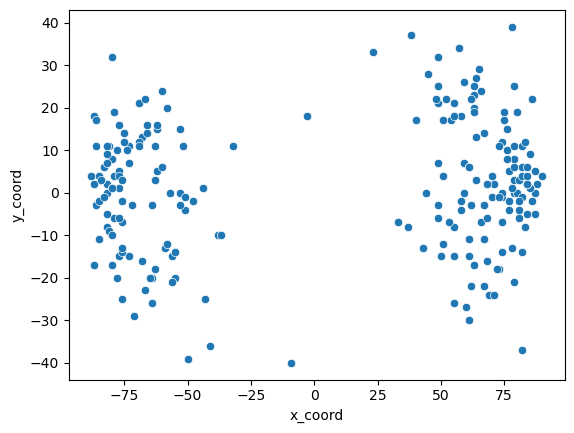

In [10]:
#plotting coordinates on scatterplot - showing shots on both sides of the ice 
sns.scatterplot(data = goal_data, x = 'x_coord', y = 'y_coord')

In [11]:
#colour palette as dictionary 
#setting hex colour codes for each player - based off team colours 
player_palette = {8471214 : '#C8102E', 
                  8477934 : '#FF4C00', 
                  8477939 : '#00205B', 
                  8477956 : '#FFB81C', 
                  8479420 : '#ADAFAA'}

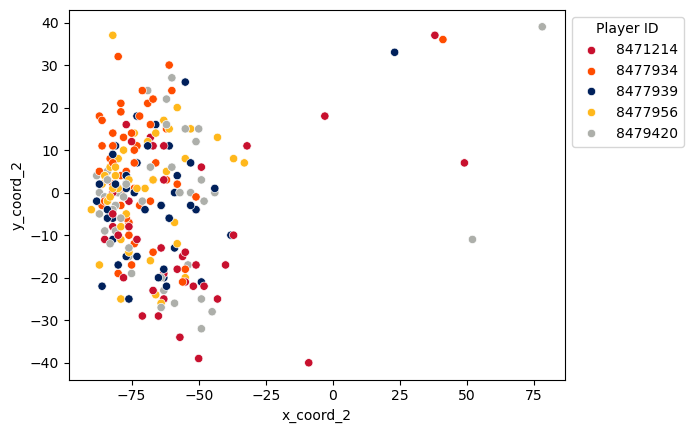

In [12]:
#plotting coordinates on scatterplot, by event_type
sns.scatterplot(data = goal_data, x = 'x_coord_2', y = 'y_coord_2', hue = 'score_player_id', palette = player_palette)
plt.legend(title='Player ID', loc='upper left', bbox_to_anchor=(1, 1))

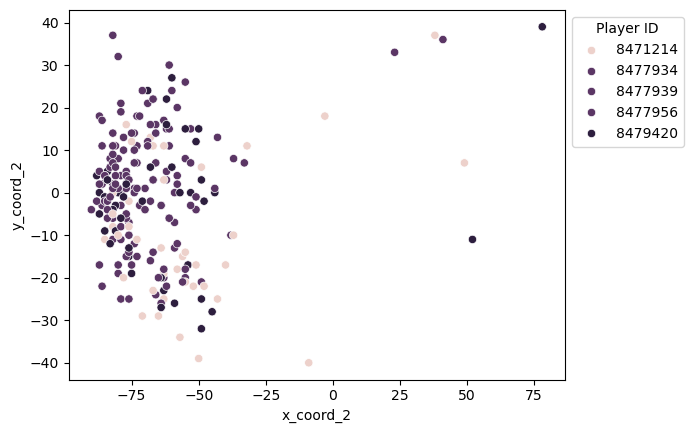

In [13]:
#plotting coordinates on scatterplot - after inverting so shots are on the same side of the rink - shows all goals from top 5 scorers 
sns.scatterplot(data = goal_data, x = 'x_coord_2', y = 'y_coord_2', hue = 'score_player_id')
plt.legend(title='Player ID', loc='upper left', bbox_to_anchor=(1, 1))

## 1. Leon Draisaitl 

#### Create dataframe with just Draisaitl

In [35]:
#creating dataframe with only data for Leon Draisaitl 
#Draisaitl's player id = 8477934

ld_data = goal_data[goal_data['score_player_id'] == 8477934]

In [36]:
#determine how many rows to make sure goal count correct
ld_data.shape

(52, 14)

In [37]:
ld_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020036,22,16,3,9:59,left,22,74,12,wrist,8477934,1,left,-74,-12


#### Graphing the Goals

In [38]:
# To keep the aspect ration correct we use a square figure size
xbnds = np.array([-100., 0])
ybnds = np.array([-100, 0])
extent = [xbnds[0],xbnds[1],ybnds[0],ybnds[1]]

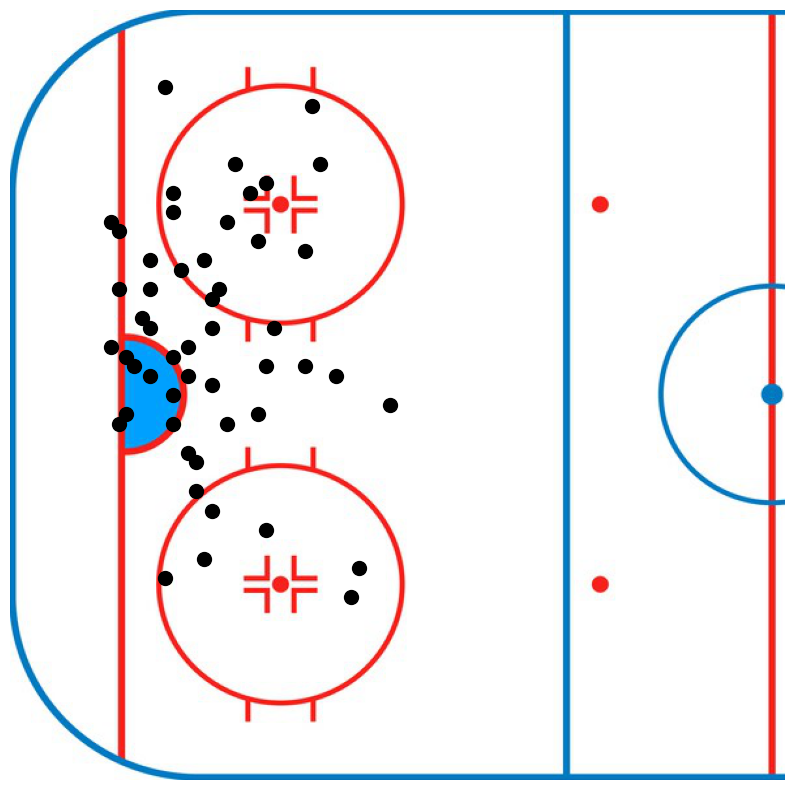

In [39]:
#all goals - one colour - matplotlib
# to read the image stored in the working directory 
rink_image = image.imread(r'C:\Users\Alex\Documents\NHL-Stats\Graphing_Shot_Locations\Images\rink_medium_half_left.jpg')

#plot
plt.figure(figsize = (10,10))
plt.scatter(x = 'x_coord_2', y = 'y_coord_2', data = ld_data, color = 'black', s = 100)
plt.axis('off')
extent = np.min(-100), np.max(0), np.min(-40), np.max(40) 
plt.imshow(rink_image, extent = extent, aspect = 'auto')
plt.savefig('ld_goals.jpg', bbox_inches='tight')
plt.show()

## 2. William Nylander 

#### Create dataframe with just Nylander

In [40]:
#creating dataframe with only data for William Nylander 
#Nylander's player id = 8477939

wn_data = goal_data[goal_data['score_player_id'] == 8477939]

In [41]:
wn_data.shape

(45, 14)

In [42]:
wn_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020026,10,5,2,19:10,left,10,82,6,snap,8477939,1,left,-82,-6


#### Graphing the Goals

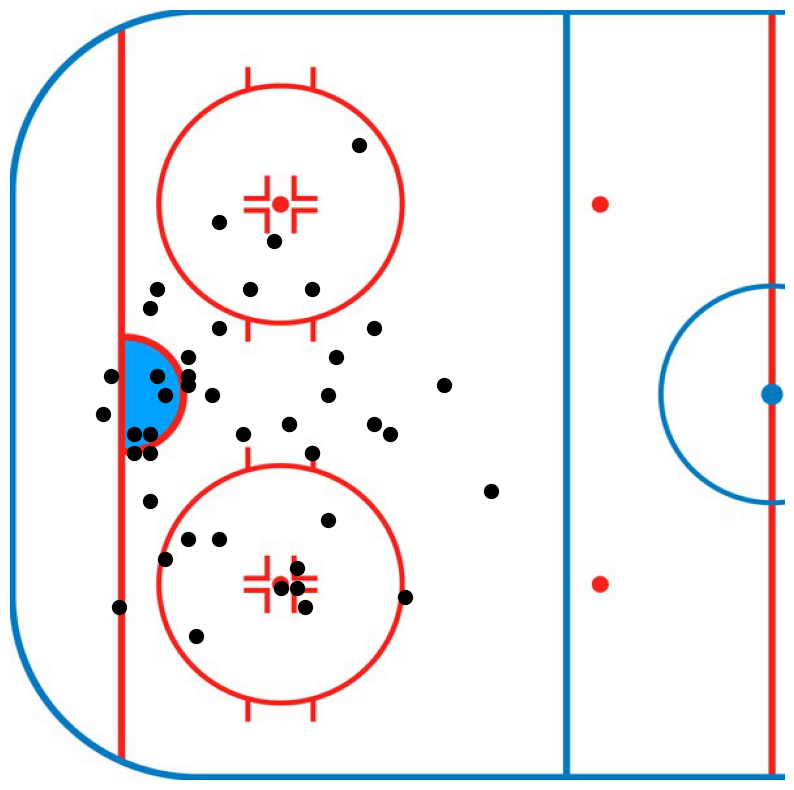

In [43]:
#all goals - one colour - matplotlib
# to read the image stored in the working directory 
rink_image = image.imread(r'C:\Users\Alex\Documents\NHL-Stats\Graphing_Shot_Locations\Images\rink_medium_half_left.jpg')

#plot
plt.figure(figsize = (10,10))
plt.scatter(x = 'x_coord_2', y = 'y_coord_2', data = wn_data, color = 'black', s = 100)
plt.axis('off')
extent = np.min(-100), np.max(0), np.min(-40), np.max(40) 
plt.imshow(rink_image, extent = extent, aspect = 'auto')
plt.savefig('wn_goals.jpg', bbox_inches='tight')
plt.show()

## T-3. Alex Ovechkin

In [44]:
#creating a dataframe with only data for Alex Ovechkin
#Ovechkin's player id = 8471214

ao_data = goal_data[goal_data['score_player_id'] == 8471214]

In [45]:
ao_data.shape

(44, 14)

In [46]:
ao_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020080,1,15,1,5:42,left,15,-77,4,tip-in,8471214,0,right,-77,4


#### Graphing the Goals

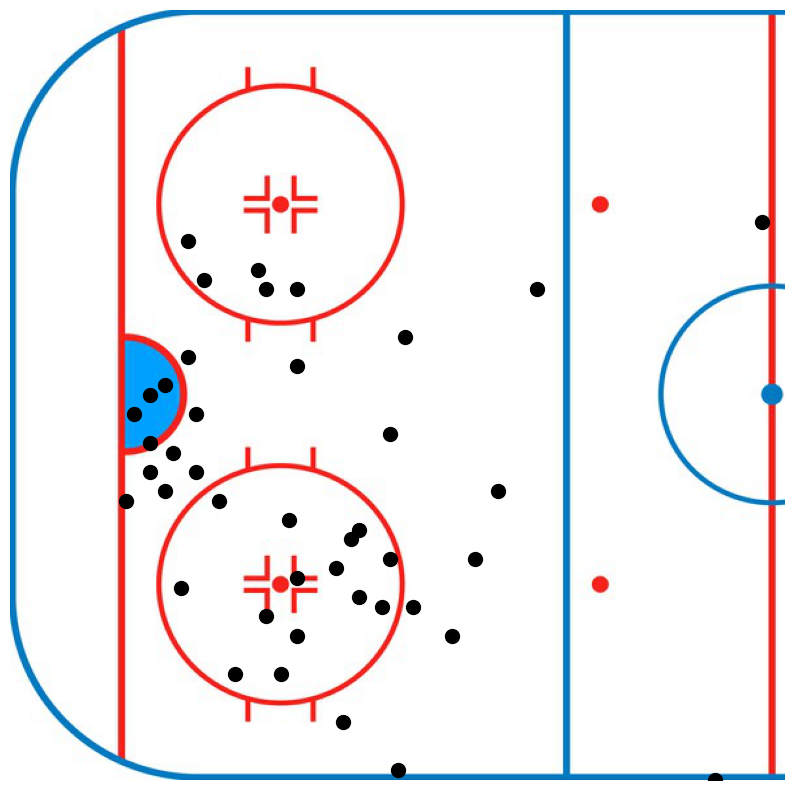

In [47]:
#all goals - one colour - matplotlib
# to read the image stored in the working directory 
rink_image = image.imread(r'C:\Users\Alex\Documents\NHL-Stats\Graphing_Shot_Locations\Images\rink_medium_half_left.jpg')

#plot
plt.figure(figsize = (10,10))
plt.scatter(x = 'x_coord_2', y = 'y_coord_2', data = ao_data, color = 'black', s = 100)
plt.axis('off')
extent = np.min(-100), np.max(0), np.min(-40), np.max(40) 
plt.imshow(rink_image, extent = extent, aspect = 'auto')
plt.savefig('ao_goals.jpg', bbox_inches='tight')
plt.show()

## T-3. Tage Thompson 

In [48]:
#creating a dataframe with only data for Tage Thompson 
#Thompson's player id = 8479420

tt_data = goal_data[goal_data['score_player_id'] == 8479420]

In [49]:
tt_data.shape

(44, 14)

In [50]:
tt_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020002,1,7,2,11:42,right,7,84,-5,poke,8479420,0,left,-84,5


#### Graphing the Goals

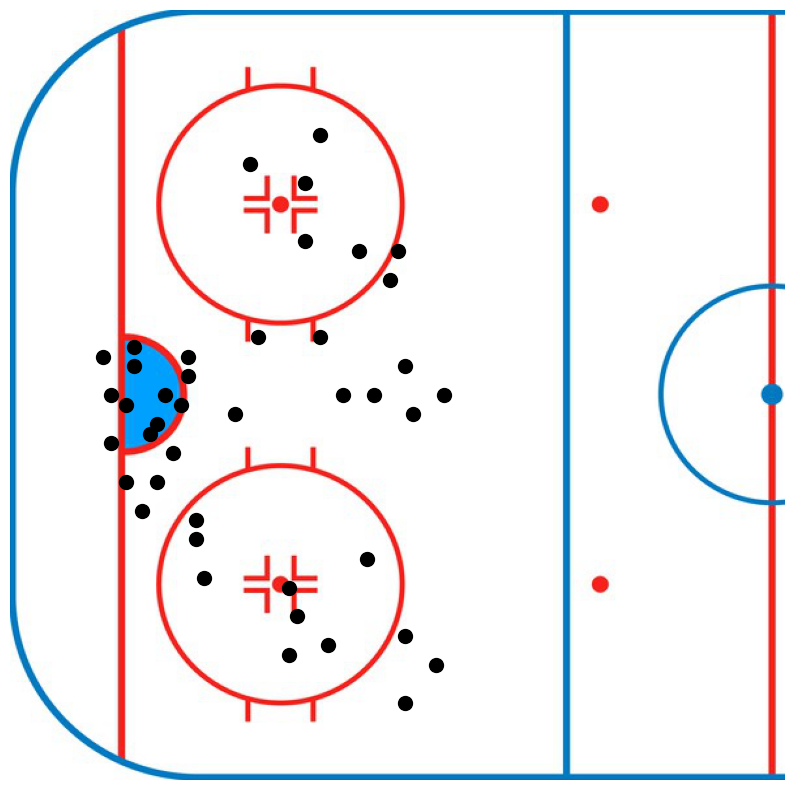

In [51]:
#all goals - one colour - matplotlib
# to read the image stored in the working directory 
rink_image = image.imread(r'C:\Users\Alex\Documents\NHL-Stats\Graphing_Shot_Locations\Images\rink_medium_half_left.jpg')

#plot
plt.figure(figsize = (10,10))
plt.scatter(x = 'x_coord_2', y = 'y_coord_2', data = tt_data, color = 'black', s = 100)
plt.axis('off')
extent = np.min(-100), np.max(0), np.min(-40), np.max(40) 
plt.imshow(rink_image, extent = extent, aspect = 'auto')
plt.savefig('tt_goals.jpg', bbox_inches='tight')
plt.show()

## 5. David Pastrnak

In [52]:
#creating a dataframe with only data for David Pastrnak 
#Pastrnak's player id = 8477956

dp_data = goal_data[goal_data['score_player_id'] == 8477956]

In [53]:
dp_data.shape

(43, 14)

In [54]:
dp_data.head(1)

,h_team_id,a_team_id,game_period,time_remaining,home_def_code,event_owner_team_id,x_coord,y_coord,shot_type,score_player_id,home_team,rinkside,x_coord_2,y_coord_2
game_id,,,,,,,,,,,,,,
2024020004,13,6,3,1:45,right,6,79,25,wrist,8477956,0,left,-79,-25


#### Graphing the Goals

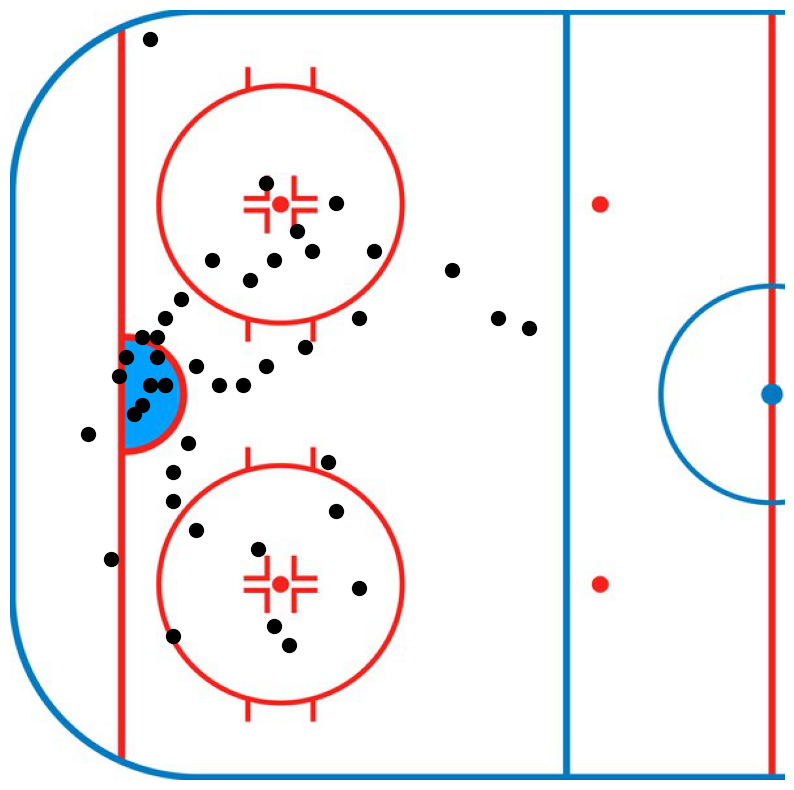

In [55]:
#all goals - one colour - matplotlib
# to read the image stored in the working directory 
rink_image = image.imread(r'C:\Users\Alex\Documents\NHL-Stats\Graphing_Shot_Locations\Images\rink_medium_half_left.jpg')

#plot
plt.figure(figsize = (10,10))
plt.scatter(x = 'x_coord_2', y = 'y_coord_2', data = dp_data, color = 'black', s = 100)
plt.axis('off')
extent = np.min(-100), np.max(0), np.min(-40), np.max(40) 
plt.imshow(rink_image, extent = extent, aspect = 'auto')
plt.savefig('dp_goals.jpg', bbox_inches='tight')
plt.show()